# Stanford RNA 3D Folding Part 2 - EDA, Preprocessing, and Modeling Intuition

This notebook is a learning-first starter notebook for the Kaggle **Stanford RNA 3D Folding Part 2** competition.

It is designed to do four things well:
1. explain why the task is hard,
2. audit the actual local competition data,
3. build reusable preprocessing helpers,
4. leave you with a practical model-routing strategy instead of a vague "try deep learning" answer.

The notebook intentionally stays dependency-light and does **not** run heavy external predictors end-to-end. Instead, it prepares the ground for them and explains when each family of models makes sense.


In [1]:
import gc
import os
import random
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

plt.style.use("ggplot")
RANDOM_SEED = 7
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Notebook environment ready.")


Notebook environment ready.


## 1. Competition framing and RNA-specific intuition

A good RNA folding workflow starts with the right mental model:

- We are predicting **five plausible 3D candidates** per target, not one guaranteed structure.
- Sequence alone is often not enough. Ligands, ions, multimers, proteins, and homologous templates all matter.
- The training set already shows ambiguity because many exact duplicate sequences appear under different target IDs and contexts.
- Part 2 is harder than the earlier 2025 challenge because more targets are novel, longer, or context-heavy.

Practical takeaways:

- **Template retrieval should be a first-class baseline**.
- **RNA-specific single-chain models** still matter on short/simple targets.
- **General biomolecular models** become more attractive as assembly and ligand context increase.
- The right workflow is usually **routing + ensembling**, not one universal predictor.

References used to shape this notebook:

- Stanford / Das Lab challenge announcements: https://daslab.stanford.edu/news/
- RNAPro post-competition paper: https://pmc.ncbi.nlm.nih.gov/articles/PMC12776560/
- Ribonanza / RibonanzaNet context: https://www.nature.com/articles/s41592-024-02487-0
- NVIDIA competition write-up: https://developer.nvidia.com/blog/stanford-das-lab-accelerates-rna-folding-research-with-nvidia-dgx-cloud/
- DRfold2: https://zhanggroup.org/DRfold2/
- RhoFold / RhoFold+: https://github.com/ml4bio/RhoFold
- Protenix: https://github.com/bytedance/Protenix
- Boltz: https://github.com/jwohlwend/boltz
- Kaggle template-search notes: https://www.kaggle.com/code/jaejohn/rna-3d-folds-tbm-only-approach
- Kaggle embedding/template notes: https://www.kaggle.com/code/shujun717/rnet2-alpha-template-search
- Additional solution coverage: https://zenn.dev/sasaki_kanji/articles/050e058db19a92


In [2]:
DEFAULT_DATA_DIR_CANDIDATES = [
    Path("/kaggle/input/stanford-rna-3d-folding-2"),
    Path("/scratch/phys/sin/rna-dataset"),
    Path.cwd() / "data",
    Path.cwd(),
]

REQUIRED_TABLES = {
    "train_sequences": "train_sequences.csv",
    "validation_sequences": "validation_sequences.csv",
    "test_sequences": "test_sequences.csv",
    "train_labels": "train_labels.csv",
    "validation_labels": "validation_labels.csv",
    "sample_submission": "sample_submission.csv",
}


def resolve_data_dir(preferred_dirs=None):
    candidates = []
    if preferred_dirs is not None:
        candidates.extend(Path(p) for p in preferred_dirs)

    env_override = os.environ.get("RNA_3D_DATA_DIR")
    if env_override:
        candidates.append(Path(env_override))

    candidates.extend(DEFAULT_DATA_DIR_CANDIDATES)

    seen = set()
    for candidate in candidates:
        candidate = Path(candidate).expanduser()
        if candidate in seen:
            continue
        seen.add(candidate)
        if candidate.exists() and all((candidate / fname).exists() for fname in REQUIRED_TABLES.values()):
            return candidate

    checked = "\n".join(str(p) for p in candidates)
    raise FileNotFoundError(
        "Could not resolve the RNA competition data directory. Checked:\n"
        f"{checked}"
    )


def load_competition_tables(data_dir=None):
    data_dir = resolve_data_dir([data_dir] if data_dir else None)

    sequence_columns = [
        "target_id",
        "sequence",
        "temporal_cutoff",
        "description",
        "stoichiometry",
        "all_sequences",
        "ligand_ids",
        "ligand_SMILES",
    ]

    tables = {
        "train_sequences": pd.read_csv(
            data_dir / REQUIRED_TABLES["train_sequences"],
            usecols=sequence_columns,
            low_memory=False,
        ),
        "validation_sequences": pd.read_csv(
            data_dir / REQUIRED_TABLES["validation_sequences"],
            usecols=sequence_columns,
            low_memory=False,
        ),
        "test_sequences": pd.read_csv(
            data_dir / REQUIRED_TABLES["test_sequences"],
            usecols=sequence_columns,
            low_memory=False,
        ),
        "train_labels": pd.read_csv(
            data_dir / REQUIRED_TABLES["train_labels"],
            dtype={
                "ID": "string",
                "resname": "string",
                "resid": "int32",
                "x_1": "float32",
                "y_1": "float32",
                "z_1": "float32",
                "chain": "string",
                "copy": "int16",
            },
            low_memory=False,
        ),
        "validation_labels": pd.read_csv(
            data_dir / REQUIRED_TABLES["validation_labels"],
            low_memory=False,
        ),
        "sample_submission": pd.read_csv(
            data_dir / REQUIRED_TABLES["sample_submission"],
            low_memory=False,
        ),
    }

    tables["msa_dir"] = data_dir / "MSA"
    tables["pdb_dir"] = data_dir / "PDB_RNA"
    tables["data_dir"] = data_dir
    return data_dir, tables


def build_target_features(seq_df):
    features = seq_df.copy()
    features["sequence"] = features["sequence"].fillna("").astype(str)
    features["seq_length"] = features["sequence"].str.len().astype("int32")
    features["temporal_cutoff"] = pd.to_datetime(features["temporal_cutoff"], errors="coerce")
    features["year"] = features["temporal_cutoff"].dt.year.astype("Int64")

    sequence_upper = features["sequence"].str.upper()
    safe_length = features["seq_length"].replace(0, np.nan)
    for base in "AUGC":
        features[f"frac_{base}"] = (sequence_upper.str.count(base) / safe_length).fillna(0.0)
    features["GC_content"] = (features["frac_G"] + features["frac_C"]).fillna(0.0)

    features["has_ligand"] = features["ligand_ids"].fillna("").ne("")
    features["multi_chain"] = features["stoichiometry"].fillna("").str.contains(";")
    features["chain_count"] = (
        features["stoichiometry"]
        .fillna("")
        .apply(lambda x: 0 if x == "" else x.count(";") + 1)
        .astype("int16")
    )
    features["ligand_count"] = (
        features["ligand_ids"]
        .fillna("")
        .apply(lambda x: 0 if x == "" else len([part for part in x.split(";") if part]))
        .astype("int16")
    )

    description_lower = features["description"].fillna("").str.lower()
    features["is_trna"] = description_lower.str.contains(r"\bt-?rna\b|\btrna\b", regex=True)
    features["is_ribosome_related"] = description_lower.str.contains("ribosom")
    features["is_riboswitch"] = description_lower.str.contains("riboswitch")
    features["is_aptamer"] = description_lower.str.contains("aptamer")
    features["is_viral"] = description_lower.str.contains("viral|virus", regex=True)

    features["sequence_dup_count"] = features.groupby("sequence")["target_id"].transform("size").astype("int16")
    features["duplicate_group_rank"] = (features.groupby("sequence").cumcount() + 1).astype("int16")

    features["model_bucket"] = np.select(
        [
            features["seq_length"] < 400,
            (features["seq_length"] >= 400) & (features["seq_length"] < 800),
            features["seq_length"] >= 800,
        ],
        ["short <400", "medium 400-799", "long >=800"],
        default="unknown",
    )

    features["eda_bucket"] = pd.cut(
        features["seq_length"],
        bins=[0, 50, 100, 200, 400, 800, 2000, 10000, np.inf],
        labels=["<=50", "51-100", "101-200", "201-400", "401-800", "801-2000", "2001-10000", ">10000"],
        include_lowest=True,
        ordered=True,
    )
    return features


def build_train_residue_table(train_sequences, train_labels):
    if "seq_length" not in train_sequences.columns or "model_bucket" not in train_sequences.columns:
        train_sequences = build_target_features(train_sequences)

    seq_meta = train_sequences[["target_id", "seq_length", "model_bucket"]].copy()
    labels = train_labels[["ID", "resname", "resid", "x_1", "y_1", "z_1", "chain", "copy"]].copy()
    labels["target_id"] = labels["ID"].str.rsplit("_", n=1).str[0]
    residue_table = labels.merge(seq_meta, on="target_id", how="left", validate="many_to_one")
    residue_table = residue_table.rename(columns={"x_1": "x", "y_1": "y", "z_1": "z"})
    residue_table = residue_table[["target_id", "resid", "resname", "chain", "copy", "x", "y", "z", "seq_length", "model_bucket"]]

    for category_col in ["target_id", "resname", "chain", "model_bucket"]:
        residue_table[category_col] = residue_table[category_col].astype("category")

    residue_table["resid"] = residue_table["resid"].astype("int32")
    residue_table["copy"] = residue_table["copy"].astype("int16")
    residue_table["seq_length"] = residue_table["seq_length"].astype("int32")
    residue_table["x"] = residue_table["x"].astype("float32")
    residue_table["y"] = residue_table["y"].astype("float32")
    residue_table["z"] = residue_table["z"].astype("float32")
    return residue_table


def reshape_validation_conformers(validation_sequences, validation_labels, sentinel=-1e18):
    labels = validation_labels.copy()
    labels["target_id"] = labels["ID"].str.rsplit("_", n=1).str[0]

    coord_cols = [c for c in labels.columns if re.fullmatch(r"[xyz]_\d+", c)]
    labels[coord_cols] = labels[coord_cols].replace(sentinel, np.nan)

    seq_meta = validation_sequences[["target_id", "sequence"]].copy()
    seq_meta["seq_length"] = seq_meta["sequence"].str.len().astype("int32")
    labels = labels.merge(seq_meta[["target_id", "seq_length"]], on="target_id", how="left", validate="many_to_one")

    conformer_ids = sorted({int(col.split("_")[1]) for col in coord_cols})
    base_cols = ["target_id", "ID", "resname", "resid", "chain", "copy", "Usage", "seq_length"]
    long_frames = []

    for conformer_id in conformer_ids:
        xyz_cols = [f"x_{conformer_id}", f"y_{conformer_id}", f"z_{conformer_id}"]
        frame = labels[base_cols + xyz_cols].copy()
        frame = frame.rename(columns={
            f"x_{conformer_id}": "x",
            f"y_{conformer_id}": "y",
            f"z_{conformer_id}": "z",
        })
        frame["conformer_id"] = conformer_id
        frame = frame.dropna(subset=["x", "y", "z"], how="all")
        if not frame.empty:
            long_frames.append(frame)

    long_df = pd.concat(long_frames, ignore_index=True)
    long_df["resid"] = long_df["resid"].astype("int32")
    long_df["copy"] = pd.to_numeric(long_df["copy"], errors="coerce").fillna(0).astype("int16")
    long_df["conformer_id"] = long_df["conformer_id"].astype("int16")
    return long_df


def summarize_msa_files(msa_dir, sample_size=192, seed=RANDOM_SEED):
    msa_dir = Path(msa_dir)
    msa_files = sorted(msa_dir.glob("*.MSA.fasta"))
    if not msa_files:
        return {
            "file_count": 0,
            "sample_count": 0,
            "sample_table": pd.DataFrame(),
            "depth_summary": pd.DataFrame(),
        }

    rng = random.Random(seed)
    sample_files = msa_files if sample_size is None or len(msa_files) <= sample_size else rng.sample(msa_files, sample_size)
    rows = []
    for msa_file in sample_files:
        depth = 0
        query_chunks = []
        reading_query = False
        with msa_file.open("r", encoding="utf-8", errors="ignore") as handle:
            for raw_line in handle:
                line = raw_line.strip()
                if not line:
                    continue
                if line.startswith(">"):
                    depth += 1
                    reading_query = depth == 1
                    continue
                if reading_query:
                    query_chunks.append(line)
        rows.append({
            "target_id": msa_file.name.replace(".MSA.fasta", "").upper(),
            "file_name": msa_file.name,
            "msa_depth": depth,
            "query_length_from_msa": len("".join(query_chunks)),
        })

    sample_table = pd.DataFrame(rows).sort_values(["msa_depth", "query_length_from_msa"], ascending=[False, False])
    depth_summary = sample_table["msa_depth"].describe(percentiles=[0.5, 0.75, 0.9, 0.95]).to_frame().T
    return {
        "file_count": len(msa_files),
        "sample_count": len(sample_table),
        "sample_table": sample_table,
        "depth_summary": depth_summary,
    }


def kabsch_rmsd(coords_a, coords_b):
    coords_a = np.asarray(coords_a, dtype=float)
    coords_b = np.asarray(coords_b, dtype=float)
    if coords_a.shape != coords_b.shape:
        raise ValueError("Coordinate arrays must have the same shape.")
    if coords_a.ndim != 2 or coords_a.shape[1] != 3:
        raise ValueError("Coordinates must have shape (n_points, 3).")

    a_centered = coords_a - coords_a.mean(axis=0, keepdims=True)
    b_centered = coords_b - coords_b.mean(axis=0, keepdims=True)
    covariance = a_centered.T @ b_centered
    u, _, vt = np.linalg.svd(covariance)
    correction = np.eye(3)
    correction[-1, -1] = np.sign(np.linalg.det(vt.T @ u.T))
    rotation = vt.T @ correction @ u.T
    aligned_a = a_centered @ rotation
    return float(np.sqrt(np.mean(np.sum((aligned_a - b_centered) ** 2, axis=1))))


print("Helper functions defined.")


Helper functions defined.


## 2. Dataset audit

We start by loading the competition tables, validating the split structure, and converting each sequence table into a target-level feature table.


In [3]:
DATA_DIR, TABLES = load_competition_tables()

train_sequences = TABLES["train_sequences"]
validation_sequences = TABLES["validation_sequences"]
test_sequences = TABLES["test_sequences"]
train_labels = TABLES["train_labels"]
validation_labels = TABLES["validation_labels"]
sample_submission = TABLES["sample_submission"]
msa_dir = TABLES["msa_dir"]
pdb_dir = TABLES["pdb_dir"]

train_features = build_target_features(train_sequences)
validation_features = build_target_features(validation_sequences)
test_features = build_target_features(test_sequences)
validation_conformers = reshape_validation_conformers(validation_sequences, validation_labels)

schema_summary = pd.DataFrame([
    {"table": "train_sequences", "rows": len(train_sequences), "columns": train_sequences.shape[1], "key_columns": ", ".join(train_sequences.columns[:5])},
    {"table": "validation_sequences", "rows": len(validation_sequences), "columns": validation_sequences.shape[1], "key_columns": ", ".join(validation_sequences.columns[:5])},
    {"table": "test_sequences", "rows": len(test_sequences), "columns": test_sequences.shape[1], "key_columns": ", ".join(test_sequences.columns[:5])},
    {"table": "train_labels", "rows": len(train_labels), "columns": train_labels.shape[1], "key_columns": ", ".join(train_labels.columns)},
    {"table": "validation_labels", "rows": len(validation_labels), "columns": validation_labels.shape[1], "key_columns": ", ".join(validation_labels.columns[:10]) + " ..."},
    {"table": "sample_submission", "rows": len(sample_submission), "columns": sample_submission.shape[1], "key_columns": ", ".join(sample_submission.columns[:8]) + " ..."},
])

split_summary = pd.DataFrame([
    {"split": "train", "targets": len(train_features), "unique_sequences": train_features["sequence"].nunique(), "min_len": int(train_features["seq_length"].min()), "median_len": int(train_features["seq_length"].median()), "mean_len": round(train_features["seq_length"].mean(), 1), "max_len": int(train_features["seq_length"].max()), "multi_chain_rate": round(train_features["multi_chain"].mean(), 3), "has_ligand_rate": round(train_features["has_ligand"].mean(), 3)},
    {"split": "validation", "targets": len(validation_features), "unique_sequences": validation_features["sequence"].nunique(), "min_len": int(validation_features["seq_length"].min()), "median_len": int(validation_features["seq_length"].median()), "mean_len": round(validation_features["seq_length"].mean(), 1), "max_len": int(validation_features["seq_length"].max()), "multi_chain_rate": round(validation_features["multi_chain"].mean(), 3), "has_ligand_rate": round(validation_features["has_ligand"].mean(), 3)},
    {"split": "test", "targets": len(test_features), "unique_sequences": test_features["sequence"].nunique(), "min_len": int(test_features["seq_length"].min()), "median_len": int(test_features["seq_length"].median()), "mean_len": round(test_features["seq_length"].mean(), 1), "max_len": int(test_features["seq_length"].max()), "multi_chain_rate": round(test_features["multi_chain"].mean(), 3), "has_ligand_rate": round(test_features["has_ligand"].mean(), 3)},
])

display(schema_summary)
display(split_summary)
print(f"Resolved data directory: {DATA_DIR}")


,table,rows,columns,key_columns
0,train_sequences,5716,8,"target_id, sequence, temporal_cutoff, description, stoichiometry"
1,validation_sequences,28,8,"target_id, sequence, temporal_cutoff, description, stoichiometry"
2,test_sequences,28,8,"target_id, sequence, temporal_cutoff, description, stoichiometry"
3,train_labels,7794971,8,"ID, resname, resid, x_1, y_1, z_1, chain, copy"
4,validation_labels,9762,126,"ID, resname, resid, x_1, y_1, z_1, x_2, y_2, z_2, x_3 ..."
5,sample_submission,9762,18,"ID, resname, resid, x_1, y_1, z_1, x_2, y_2 ..."


,split,targets,unique_sequences,min_len,median_len,mean_len,max_len,multi_chain_rate,has_ligand_rate
0,train,5716,3432,10,94,1363.7,125580,0.414,0.673
1,validation,28,28,19,91,348.6,4640,0.036,0.500
2,test,28,28,19,91,348.6,4640,0.036,0.500


Resolved data directory: /scratch/phys/sin/rna-dataset


In [4]:
train_label_counts = (
    train_labels["ID"].str.rsplit("_", n=1).str[0].value_counts().rename_axis("target_id").reset_index(name="label_rows")
)
train_integrity = train_features.merge(train_label_counts, on="target_id", how="left", validate="one_to_one")
train_test_overlap = train_features["sequence"].isin(test_features["sequence"]).sum()
train_validation_overlap = train_features["sequence"].isin(validation_features["sequence"]).sum()
validation_test_id_match = validation_features["target_id"].tolist() == test_features["target_id"].tolist()

raw_validation_has_sentinels = bool((validation_labels.filter(regex=r"^[xyz]_\d+$") == -1e18).to_numpy().any())
reshaped_validation_has_sentinels = bool((validation_conformers[["x", "y", "z"]] == -1e18).to_numpy().any())

msa_target_ids = {path.name.replace(".MSA.fasta", "").upper() for path in msa_dir.glob("*.MSA.fasta")}
train_msa_missing = set(train_features["target_id"].str.upper()) - msa_target_ids
validation_msa_missing = set(validation_features["target_id"].str.upper()) - msa_target_ids
test_msa_missing = set(test_features["target_id"].str.upper()) - msa_target_ids

assert Path("/kaggle/input/stanford-rna-3d-folding-2") in DEFAULT_DATA_DIR_CANDIDATES
assert Path(DATA_DIR).exists()
assert train_integrity["label_rows"].notna().all()
assert (train_integrity["seq_length"] == train_integrity["label_rows"]).all()
assert train_test_overlap == 0
assert train_validation_overlap == 0
assert validation_test_id_match
assert raw_validation_has_sentinels
assert not reshaped_validation_has_sentinels
assert not train_msa_missing
assert not validation_msa_missing
assert not test_msa_missing

validation_conformer_summary = (
    validation_conformers.groupby("target_id")
    .agg(seq_length=("seq_length", "first"), observed_conformers=("conformer_id", "nunique"), residues=("resid", "count"))
    .sort_values(["observed_conformers", "seq_length"], ascending=[False, False])
)

display(train_integrity[["target_id", "seq_length", "label_rows"]].head())
display(validation_conformer_summary)
print("All notebook assertions passed.")


,target_id,seq_length,label_rows
0,4TNA,76,76
1,6TNA,76,76
2,1TRA,76,76
3,1TN2,76,76
4,1TN1,76,76


,seq_length,observed_conformers,residues
target_id,,,
9LJN,71,11,781
9JFO,195,3,369
9EBP,81,3,243
9ZCC,1460,2,2920
9G4J,334,2,508
9JFS,246,2,276
9E9Q,101,2,202
9OD4,23,2,46
9MME,4640,1,4168


All notebook assertions passed.


## 3. Difficulty analysis

This is where the competition starts to reveal its shape: extreme length tails, many complex assemblies, internal duplicate-sequence groups, and sparse validation conformers.


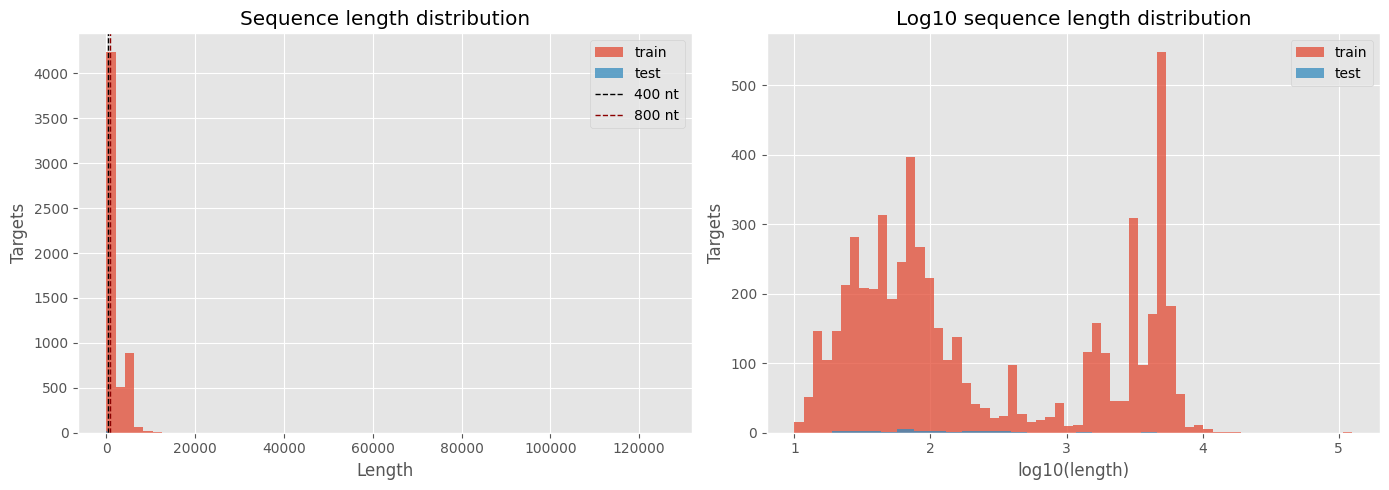

,train,validation,test
model_bucket,,,
short <400,3654,25,25
long >=800,1943,2,2
medium 400-799,119,1,1


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_features["seq_length"], bins=60, alpha=0.75, label="train")
axes[0].hist(test_features["seq_length"], bins=20, alpha=0.75, label="test")
axes[0].axvline(400, color="black", linestyle="--", linewidth=1, label="400 nt")
axes[0].axvline(800, color="darkred", linestyle="--", linewidth=1, label="800 nt")
axes[0].set_title("Sequence length distribution")
axes[0].set_xlabel("Length")
axes[0].set_ylabel("Targets")
axes[0].legend()

axes[1].hist(np.log10(train_features["seq_length"]), bins=60, alpha=0.75, label="train")
axes[1].hist(np.log10(test_features["seq_length"]), bins=20, alpha=0.75, label="test")
axes[1].set_title("Log10 sequence length distribution")
axes[1].set_xlabel("log10(length)")
axes[1].set_ylabel("Targets")
axes[1].legend()
plt.tight_layout()
plt.show()

model_bucket_counts = pd.concat([
    train_features["model_bucket"].value_counts().rename("train"),
    validation_features["model_bucket"].value_counts().rename("validation"),
    test_features["model_bucket"].value_counts().rename("test"),
], axis=1).fillna(0).astype(int)
display(model_bucket_counts)

temporal_view = train_features.sample(min(2500, len(train_features)), random_state=RANDOM_SEED)
temporal_fig = px.scatter(
    temporal_view,
    x="year",
    y="seq_length",
    color="model_bucket",
    symbol="multi_chain",
    log_y=True,
    hover_data=["target_id", "has_ligand", "ligand_count", "chain_count"],
    title="Train targets by release year and sequence length",
)
temporal_fig.update_layout(height=500)
temporal_fig


,metric,value
0,train targets,5716.000
1,validation targets,28.000
2,median train length,94.000
3,max train length,125580.000
4,multi-chain train fraction,0.414
5,ligand-bearing train fraction,0.673
6,duplicate targets,3203.000
7,unique duplicated sequences,919.000


,n_targets,seq_length,unique_ligand_sets,unique_stoichiometries,first_target
0,46,4810,28,4,1VY4
1,36,5475,33,5,4V7R
2,29,3022,27,1,6PJ6
3,27,3675,10,9,5JCS
4,26,1542,5,2,4ADV
5,26,1522,8,1,4DR1
6,24,955,10,1,6RW4
7,24,27,7,1,480D
8,22,1628,8,2,5OOL
9,17,4687,1,2,7PAH


Manual inspection targets


,target_id,seq_length,description,stoichiometry,ligand_ids
261,1G2E,10,CRYSTAL STRUCTURE OF HUD AND AU-RICH ELEMENT OF THE TUMOR NECROSIS FACTOR ALPHA RNA,B:1,NaN


,target_id,seq_length,description,stoichiometry,ligand_ids
1997,4V3P,125580,The molecular structure of the left-handed supra-molecular helix of eukaryotic polyribosomes,S3:23;L2:23;L1:23;L3:23;S1:23;S2:23,NaN


,target_id,seq_length,temporal_cutoff,stoichiometry,ligand_ids,description
1851,1VY4,4810,2014-08-20,AX:1;AW:2;AV:1;BA:1;BB:1;AA:1,K;MG;SF4;ZN,Crystal structure of the Thermus thermophilus 70S ribosome in the pre-attack state of peptide bond formation contain...
1852,1VY5,4810,2014-08-20,AX:1;AW:2;AV:1;BA:1;BB:1;AA:1,K;MG;SF4;ZN,Crystal structure of the Thermus thermophilus 70S ribosome in the post-catalysis state of peptide bond formation con...
1881,4W2F,4810,2014-10-15,AX:1;AW:2;AV:1;BA:1;BB:1;AA:1,K;MG;SF4;UAM;ZN,"Crystal structure of the Thermus thermophilus 70S ribosome in complex with amicoumacin, mRNA and three deacylated tR..."
1882,4W2G,4810,2014-10-15,AX:1;AW:2;AV:1;BA:1;BB:1;AA:1,K;MG;PCY;SF4;ZN,"Crystal structure of the Thermus thermophilus 70S ribosome in complex with pactamycin (soaked), mRNA and three deacy..."
1883,4W2I,4810,2014-10-15,AX:1;AW:2;AV:1;BA:1;BB:1;AA:1,K;MG;NEG;SF4;ZN,"Crystal structure of the Thermus thermophilus 70S ribosome in complex with negamycin, mRNA and three deacylated tRNA..."
1946,4WPO,4810,2015-01-28,BX:1;BW:2;BV:1;AA:1;AB:1;BA:1,GDP;K;MG;SF4;ZN,Crystal structure of the Thermus thermophilus 70S ribosome in complex with elongation factor G in the pre-translocat...
1973,4Y4P,4810,2015-03-18,1x:1;1w:2;1v:1;1A:1;1B:1;1a:1,K;MG;SF4;ZN,"Crystal structure of the Thermus thermophilus 70S ribosome with rRNA modifications and bound to mRNA and A-, P- and ..."
2205,5J4B,4810,2016-04-27,1x:1;1w:2;1v:1;1A:1;1B:1;1a:1,CPT;K;MG;SF4;ZN,Crystal structure of the Thermus thermophilus 70S ribosome in complex with cisplatin (co-crystallized) and bound to ...
2206,5J4C,4810,2016-04-27,1x:1;1w:2;1v:1;1A:1;1B:1;1a:1,CPT;K;MG;SF4;ZN,Crystal structure of the Thermus thermophilus 70S ribosome in complex with cisplatin (soaked) and bound to mRNA and ...
2236,5J8B,4810,2016-05-25,x:1;w:2;v:1;A:1;B:1;a:1,GCP;MG;SF4;ZN,Crystal structure of Elongation Factor 4 (EF-4/LepA) in complex with GDPCP bound to the Thermus thermophilus 70S rib...


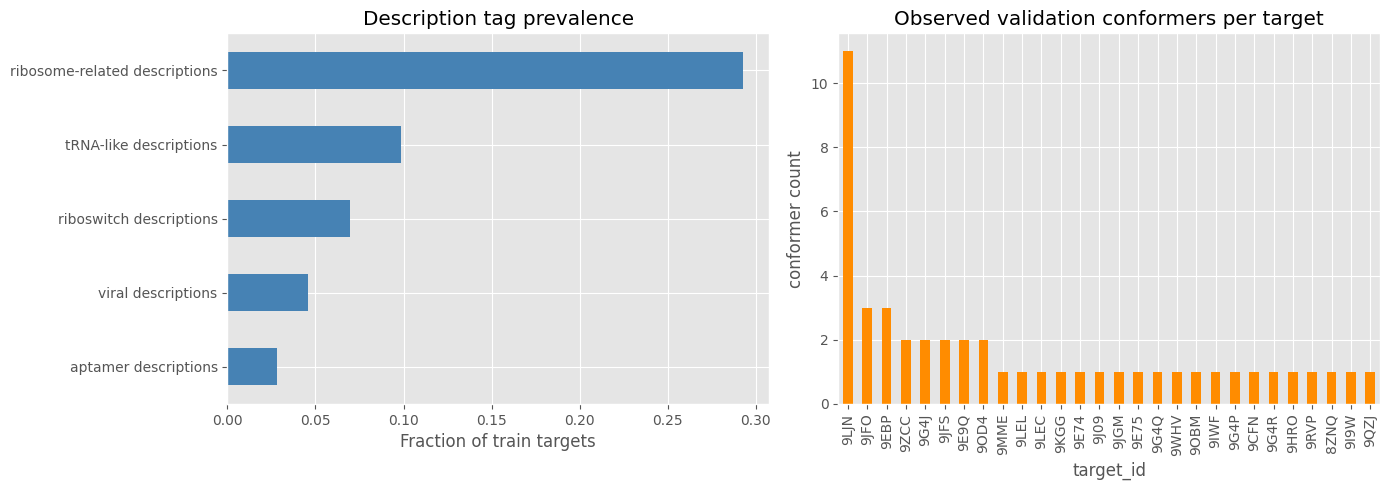

count  median    mean     max
multi_chain has_ligand                               
False       False        1356    48.0   314.2   11662
            True         1995    75.0   266.4    7012
True        False         512  3023.0  2882.6  125580
            True         1853  3044.0  2893.4   11884

In [6]:
duplicate_cluster_summary = (
    train_features.groupby("sequence")
    .agg(n_targets=("target_id", "size"), seq_length=("seq_length", "first"), unique_ligand_sets=("ligand_ids", pd.Series.nunique), unique_stoichiometries=("stoichiometry", pd.Series.nunique), first_target=("target_id", "first"))
    .query("n_targets > 1")
    .sort_values(["n_targets", "seq_length"], ascending=[False, False])
)

short_example = train_features.nsmallest(1, "seq_length")[["target_id", "seq_length", "description", "stoichiometry", "ligand_ids"]]
long_example = train_features.nlargest(1, "seq_length")[["target_id", "seq_length", "description", "stoichiometry", "ligand_ids"]]
top_duplicate_sequence = duplicate_cluster_summary.index[0]
duplicate_example = train_features.loc[
    train_features["sequence"] == top_duplicate_sequence,
    ["target_id", "seq_length", "temporal_cutoff", "stoichiometry", "ligand_ids", "description"],
].head(12)

difficulty_summary = pd.DataFrame([
    {"metric": "train targets", "value": len(train_features)},
    {"metric": "validation targets", "value": len(validation_features)},
    {"metric": "median train length", "value": int(train_features["seq_length"].median())},
    {"metric": "max train length", "value": int(train_features["seq_length"].max())},
    {"metric": "multi-chain train fraction", "value": round(train_features["multi_chain"].mean(), 3)},
    {"metric": "ligand-bearing train fraction", "value": round(train_features["has_ligand"].mean(), 3)},
    {"metric": "duplicate targets", "value": int((train_features["sequence_dup_count"] > 1).sum())},
    {"metric": "unique duplicated sequences", "value": int((train_features["sequence"].value_counts() > 1).sum())},
])

prevalence_summary = pd.DataFrame(
    {"fraction": [train_features["is_trna"].mean(), train_features["is_ribosome_related"].mean(), train_features["is_riboswitch"].mean(), train_features["is_aptamer"].mean(), train_features["is_viral"].mean()]},
    index=["tRNA-like descriptions", "ribosome-related descriptions", "riboswitch descriptions", "aptamer descriptions", "viral descriptions"],
).sort_values("fraction", ascending=False)

complexity_table = train_features.groupby(["multi_chain", "has_ligand"])["seq_length"].agg(["count", "median", "mean", "max"]).round(1)

display(difficulty_summary)
display(duplicate_cluster_summary.head(10).reset_index(drop=True))
print("Manual inspection targets")
display(short_example)
display(long_example)
display(duplicate_example)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
prevalence_summary["fraction"].sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Description tag prevalence")
axes[0].set_xlabel("Fraction of train targets")
validation_conformer_summary["observed_conformers"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Observed validation conformers per target")
axes[1].set_xlabel("target_id")
axes[1].set_ylabel("conformer count")
plt.tight_layout()
plt.show()

display(complexity_table)


## 4. Feature engineering and preprocessing

The preprocessing goal here is to create clean target-level and residue-level tables that support template retrieval, routing, and later export into heavier inference pipelines.


In [7]:
model_ready_columns = [
    "target_id", "seq_length", "model_bucket", "eda_bucket", "year", "has_ligand", "ligand_count", "multi_chain", "chain_count", "sequence_dup_count", "GC_content", "frac_A", "frac_U", "frac_G", "frac_C", "is_trna", "is_ribosome_related", "is_riboswitch", "is_aptamer", "is_viral",
]

train_model_table = train_features[model_ready_columns].copy()
validation_model_table = validation_features[model_ready_columns].copy()
test_model_table = test_features[model_ready_columns].copy()

train_residue_table = build_train_residue_table(train_features, train_labels)
del train_labels
gc.collect()

display(train_model_table.head())
display(train_residue_table.head())
print(f"Target-level train table shape: {train_model_table.shape} | Residue-level train table shape: {train_residue_table.shape}")


,target_id,seq_length,model_bucket,eda_bucket,year,has_ligand,ligand_count,multi_chain,chain_count,sequence_dup_count,GC_content,frac_A,frac_U,frac_G,frac_C,is_trna,is_ribosome_related,is_riboswitch,is_aptamer,is_viral
0,4TNA,76,short <400,51-100,1978,True,1,False,1,14,0.539474,0.236842,0.223684,0.302632,0.236842,True,False,False,False,False
1,6TNA,76,short <400,51-100,1979,True,1,False,1,14,0.539474,0.236842,0.223684,0.302632,0.236842,True,False,False,False,False
2,1TRA,76,short <400,51-100,1986,True,1,False,1,14,0.539474,0.236842,0.223684,0.302632,0.236842,False,False,False,False,False
3,1TN2,76,short <400,51-100,1986,True,3,False,1,14,0.539474,0.236842,0.223684,0.302632,0.236842,True,False,False,False,False
4,1TN1,76,short <400,51-100,1987,True,3,False,1,14,0.539474,0.236842,0.223684,0.302632,0.236842,True,False,False,False,False


,target_id,resid,resname,chain,copy,x,y,z,seq_length,model_bucket
0,157D,1,C,A,1,4.843,-5.640,13.265,24,short <400
1,157D,2,G,A,1,3.385,-7.613,8.267,24,short <400
2,157D,3,C,A,1,2.158,-6.751,2.949,24,short <400
3,157D,4,G,A,1,2.669,-4.843,-1.773,24,short <400
4,157D,5,A,A,1,3.509,0.239,-4.045,24,short <400


Target-level train table shape: (5716, 20) | Residue-level train table shape: (7794971, 10)


In [8]:
small_duplicate_pool = train_features.query("sequence_dup_count > 1 and seq_length <= 200").copy()
if not small_duplicate_pool.empty:
    chosen_sequence = small_duplicate_pool.sort_values(["sequence_dup_count", "seq_length"], ascending=[False, True]).iloc[0]["sequence"]
    duplicate_pair_targets = train_features.loc[train_features["sequence"] == chosen_sequence, "target_id"].tolist()[:2]
    duplicate_pair_coords = []
    for target_id in duplicate_pair_targets:
        coords = train_residue_table.loc[train_residue_table["target_id"] == target_id, ["x", "y", "z"]].to_numpy()
        duplicate_pair_coords.append(coords)

    duplicate_pair_rmsd = kabsch_rmsd(duplicate_pair_coords[0], duplicate_pair_coords[1])
    duplicate_pair_metadata = train_features.loc[
        train_features["target_id"].isin(duplicate_pair_targets),
        ["target_id", "seq_length", "stoichiometry", "ligand_ids", "description"],
    ]
    print(f"Kabsch RMSD for one duplicated short-sequence pair: {duplicate_pair_rmsd:.3f}")
    display(duplicate_pair_metadata)
else:
    print("No short duplicate pairs were found for the RMSD example.")


Kabsch RMSD for one duplicated short-sequence pair: 0.328


,target_id,seq_length,stoichiometry,ligand_ids,description
176,480D,27,A:1,NaN,CRYSTAL STRUCTURE OF THE SARCIN/RICIN DOMAIN FROM E. COLI 23 S RRNA
177,483D,27,A:1,NaN,CRYSTAL STRUCTURE OF THE SARCIN/RICIN DOMAIN FROM E. COLI 23 S RRNA


## 5. MSA and structure assets

The local dataset already ships with an `MSA/` directory and a `PDB_RNA/` directory. That matters because it nudges us toward a workflow that keeps template search and homolog information near the center of the pipeline.


,split,targets,msa_files_present
0,train,5716,5716
1,validation,28,28
2,test,28,28


,asset,count
0,MSA files,5744
1,Sampled MSA files for depth stats,192
2,PDB / mmCIF structure files,9564


,count,mean,std,min,50%,75%,90%,95%,max
msa_depth,192.0,11402.635417,16723.319638,1.0,2620.5,18237.5,40855.6,45721.4,79064.0


,target_id,file_name,msa_depth,query_length_from_msa
92,9GGR,9GGR.MSA.fasta,79064,9491
86,3JAJ,3JAJ.MSA.fasta,74574,5958
179,7NRC,7NRC.MSA.fasta,58382,5630
27,8Y0X,8Y0X.MSA.fasta,55644,7302
81,5LZD,5LZD.MSA.fasta,51269,4785
26,8YDI,8YDI.MSA.fasta,51107,4852
133,6WD3,6WD3.MSA.fasta,47918,4810
183,6WD4,6WD4.MSA.fasta,47918,4810
184,6WDC,6WDC.MSA.fasta,47918,4810
18,4V7H,4V7H.MSA.fasta,46344,5277


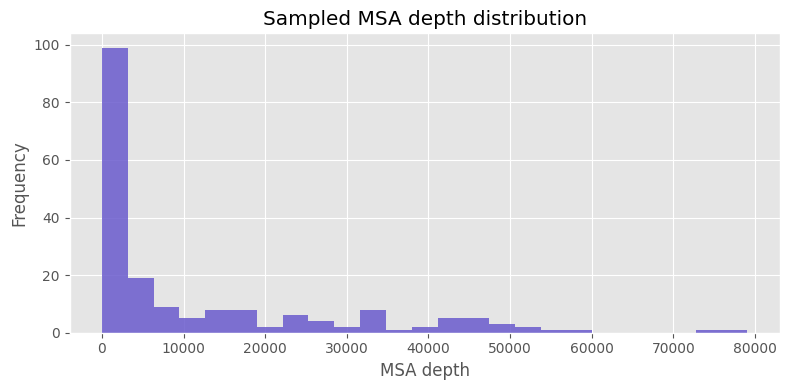

In [9]:
msa_summary = summarize_msa_files(msa_dir, sample_size=192)

msa_coverage = pd.DataFrame([
    {"split": "train", "targets": len(train_features), "msa_files_present": len(set(train_features["target_id"].str.upper()) & msa_target_ids)},
    {"split": "validation", "targets": len(validation_features), "msa_files_present": len(set(validation_features["target_id"].str.upper()) & msa_target_ids)},
    {"split": "test", "targets": len(test_features), "msa_files_present": len(set(test_features["target_id"].str.upper()) & msa_target_ids)},
])

pdb_files = sorted(pdb_dir.glob("*.cif"))
pdb_asset_summary = pd.DataFrame([
    {"asset": "MSA files", "count": msa_summary["file_count"]},
    {"asset": "Sampled MSA files for depth stats", "count": msa_summary["sample_count"]},
    {"asset": "PDB / mmCIF structure files", "count": len(pdb_files)},
])

display(msa_coverage)
display(pdb_asset_summary)
display(msa_summary["depth_summary"])
display(msa_summary["sample_table"].head(10))

fig, ax = plt.subplots(figsize=(8, 4))
msa_summary["sample_table"]["msa_depth"].plot(kind="hist", bins=25, ax=ax, color="slateblue", alpha=0.85)
ax.set_title("Sampled MSA depth distribution")
ax.set_xlabel("MSA depth")
plt.tight_layout()
plt.show()


## 6. Modeling playbook

The data audit points to a strategy, not just a model list.

- Many targets are short and single-chain, but a large fraction are also long, multi-chain, or ligand-bearing.
- Exact duplicate sequences inside train are a strong hint that **template/context retrieval** should be a baseline.
- Validation conformers are sparse and uneven, so "predict one coordinate tensor directly from CSV supervision" is too brittle as a first approach.


In [10]:
model_playbook = pd.DataFrame([
    {"route": "Template retrieval / TBM first", "best_for": "Every target as a baseline, especially homolog-rich cases", "why": "The 2025 competition and RNAPro paper both suggest templates are often the strongest first signal.", "watch_out": "Exact sequence match is not enough; context and ligands still matter."},
    {"route": "DRfold2 or RhoFold+", "best_for": "Short, mostly single-chain RNAs", "why": "RNA-specific inductive bias is valuable when chain complexity is low.", "watch_out": "Less attractive as the primary route for long or ligand-heavy assemblies."},
    {"route": "Protenix", "best_for": "Long targets, multimeric targets, ligand-bearing targets", "why": "General biomolecular modeling becomes more useful as assembly context dominates.", "watch_out": "Heavier compute and more orchestration than notebook-only workflows."},
    {"route": "Boltz ensemble complement", "best_for": "Diversity and alternate hypotheses", "why": "The competition asks for five candidates, so diversity has direct value.", "watch_out": "Use as a complement, not a replacement for template search."},
    {"route": "Direct coordinate regressor from CSVs", "best_for": "Not the first move", "why": "The local data is too heterogeneous and the label regime is too sparse for this to be the best starting point.", "watch_out": "High risk of overfitting family/context shortcuts."},
])

def recommend_route(row):
    template_note = "template retrieval baseline"
    if row["multi_chain"] or row["has_ligand"] or row["seq_length"] >= 800:
        return f"{template_note} + Protenix primary + Boltz diversity"
    if row["seq_length"] < 400:
        return f"{template_note} + DRfold2/RhoFold+ primary"
    return f"{template_note} + DRfold2/RhoFold+ primary with Protenix fallback"

routing_preview = test_features[["target_id", "seq_length", "model_bucket", "multi_chain", "has_ligand", "ligand_count", "chain_count"]].copy()
routing_preview["recommended_route"] = routing_preview.apply(recommend_route, axis=1)

experiment_order = pd.DataFrame([
    {"step": 1, "experiment": "Template baseline", "goal": "Establish a strong retrieval-first benchmark."},
    {"step": 2, "experiment": "DRfold2 or RhoFold+ on short/simple targets", "goal": "Measure RNA-specific gains where they are most plausible."},
    {"step": 3, "experiment": "Protenix on long, ligand-bearing, or multi-chain targets", "goal": "Cover the complex end of the target distribution."},
    {"step": 4, "experiment": "Boltz diversity ensemble", "goal": "Increase candidate diversity for five-structure submissions."},
    {"step": 5, "experiment": "Custom fusion / ranking", "goal": "Only after strong building blocks already exist."},
])

display(model_playbook)
display(routing_preview.head(15))
display(experiment_order)


,route,best_for,why,watch_out
0,Template retrieval / TBM first,"Every target as a baseline, especially homolog-rich cases",The 2025 competition and RNAPro paper both suggest templates are often the strongest first signal.,Exact sequence match is not enough; context and ligands still matter.
1,DRfold2 or RhoFold+,"Short, mostly single-chain RNAs",RNA-specific inductive bias is valuable when chain complexity is low.,Less attractive as the primary route for long or ligand-heavy assemblies.
2,Protenix,"Long targets, multimeric targets, ligand-bearing targets",General biomolecular modeling becomes more useful as assembly context dominates.,Heavier compute and more orchestration than notebook-only workflows.
3,Boltz ensemble complement,Diversity and alternate hypotheses,"The competition asks for five candidates, so diversity has direct value.","Use as a complement, not a replacement for template search."
4,Direct coordinate regressor from CSVs,Not the first move,The local data is too heterogeneous and the label regime is too sparse for this to be the best starting point.,High risk of overfitting family/context shortcuts.


,target_id,seq_length,model_bucket,multi_chain,has_ligand,ligand_count,chain_count,recommended_route
0,8ZNQ,30,short <400,False,True,1,1,template retrieval baseline + Protenix primary + Boltz diversity
1,9IWF,69,short <400,False,True,3,1,template retrieval baseline + Protenix primary + Boltz diversity
2,9JGM,210,short <400,False,True,2,1,template retrieval baseline + Protenix primary + Boltz diversity
3,9MME,4640,long >=800,False,True,2,1,template retrieval baseline + Protenix primary + Boltz diversity
4,9J09,214,short <400,False,False,0,1,template retrieval baseline + DRfold2/RhoFold+ primary
5,9E9Q,101,short <400,False,True,1,1,template retrieval baseline + Protenix primary + Boltz diversity
6,9CFN,59,short <400,False,True,2,1,template retrieval baseline + Protenix primary + Boltz diversity
7,9OBM,73,short <400,False,False,0,1,template retrieval baseline + DRfold2/RhoFold+ primary
8,9G4P,68,short <400,True,True,1,2,template retrieval baseline + Protenix primary + Boltz diversity
9,9G4Q,104,short <400,False,True,2,1,template retrieval baseline + Protenix primary + Boltz diversity


,step,experiment,goal
0,1,Template baseline,Establish a strong retrieval-first benchmark.
1,2,DRfold2 or RhoFold+ on short/simple targets,Measure RNA-specific gains where they are most plausible.
2,3,"Protenix on long, ligand-bearing, or multi-chain targets",Cover the complex end of the target distribution.
3,4,Boltz diversity ensemble,Increase candidate diversity for five-structure submissions.
4,5,Custom fusion / ranking,Only after strong building blocks already exist.


## Final takeaways

If I were starting this competition from scratch with this dataset, I would do the following:

- keep **template retrieval** in the loop from day one,
- route short/simple targets toward **RNA-specific models**,
- route long or context-heavy targets toward **Protenix-style biomolecular models**,
- use **Boltz** for diversity rather than as the only model,
- avoid starting with a single end-to-end coordinate regressor trained only on these CSVs.

This notebook leaves you with reusable tables, sanity-checked assumptions, and a cleaner intuition for why the problem should be attacked as **retrieval + routing + ensemble design** rather than one monolithic model.
